# Unified MDTF/GFDL/NCAR Analysis Notebook Template

* More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)  

* To run this notebook, please set the correct kernel first. The commands to create a conda environment and make it accessible from Jupyter notebook (only need to do this once for each environment) are below:
```python
conda create -n esnb python=3.12
conda activate esnb
pip install esnb gcsfs
pip install ipykernel
python -m ipykernel install --user --name esnb
```

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2

import importlib
import collections
import io, sys, os
import yaml, json

# WMT add pathlib package
from pathlib import Path
import xarray as xr
import numpy as np
import warnings
warnings.simplefilter("ignore")

# Set local environment variables 
#os.environ["ESNB_LOG_LEVEL"] = "DEBUG"
os.environ['CODE_ROOT'] = '/scratch/leih/mdtf/MDTF-diagnostics'
os.environ['WORK_DIR'] = '/scratch/leih/mdtf/wkdir/MDTF_output/precip_pdfs'

## About the POD: precipitation probability distributions

This POD calculates the precipitation probability distributions linked to major system types across the globe by using high-resolution satellite observations, reanalysis and CMIP6 model simulations. For precipitation, its probability density function (PDF) has a form closer to a Gamma distribution, with a scale-free regime at low intensities and a scale-dependent regime at high intensities. 

Precipitation PDFs can be characterized by two parameters: a power-law exponent <font color="red">$\tau$ </font>governing the low to moderate precipitation range, and a probability-decay intensity scale <font color="red">P<sub>L</sub></font> governing the high-intensity precipitation range, providing a more tailored representation than mean and standard deviation. The precipitation PDFs can be calculated for various weather systems, seasons, and regions. The data used in this POD includes:

- Integrated Multi-satellitE Retrievals for GPM (IMERG) Final Run product, Version 06B
- ECMWF ERA5 reanalysis
------------------------------------------
- A minimum of one year of data at 3-hourly temporal resolution is recommended to ensure a sufficient sample size.
- This POD is designed for models with relatively high horizontal resolution (≤ 0.5°). Conservative regridding is applied by default to ensure consistent comparisons between model outputs and the observational reference (GPM-IMERG + ERA5).
- Detailed descriptions of the POD are documeneted in <font color="red">"diagnostics/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst"</font>
-------------------------------------------

## Jupyter ESNB notebook POD settings
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD
- Set the runtime configurations
### [Section 2: Load Data from Catalog Files](#section2)
- ESNB option
- Intake-ESM option
### [Section 3: Precipitation PDFs Computation](#section3)
- Step 1. Precipitation data regridding
- Step 2. Calculate precipitation PDF and probability-decay intensity scale P<sub>L</sub>
- Step 3. Placeholder
### [Section 4: Results Visualization](#section4)
- Plot precipitation PDFs for specific regions 
- Plot precipitation PDFs for seasons 
- Similar plots but with x = P/P<sub>L</sub>
- Model vs observation comparison
### [Section 5: More about this POD](#section5)
- Placeholder
- Placeholder

<a id='section1'> </a>
##  Section 1: Prepare POD Settings

In [2]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.getenv('CODE_ROOT')
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /scratch/leih/mdtf/MDTF-diagnostics


- If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [3]:
# Define a mode (leave "prod" for now)
mode = "interactive"

# Verbosity
verbose = True

### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- Each POD may have different settings, POD developers can change theirs accordingly

In [4]:
if (mode == "interactive"):
  settings_dict = {
    "settings": {

        # ---------------------------------------------------
        # The pod_env_vars are used in the POD, not required by the MDTF framework
        # ---------------------------------------------------
        "pod_options": {
            # Options of running processes. Set "False" if this process has been completed before. 
            # "experiment_name": "MPI-ESM1-2-HR_historical_r1i1p1f1.json",
            "run_precip_pdfs": "True",
            "plot_precip_pdfs": "True",
            
            # The time range of the precipitation PDF analysis. 
            "start_time": "20050101.0600",
            "end_time": "20091231.1800",
            # The latitude range: 
            "latitude_max": 30,
            "latitude_min": -30,
            # The longitude range: 
            "longitude_max": 60,
            "longitude_min": 0,
            # Regions with center lon & lat:
            "Region": {
                "WPaci": {
                    "center_lat": 130,
                    "center_lon": 25
                },
                "Amazon": {
                    "center_lat": -10,
                    "center_lon": -50
                },
                # "WConUS"
            }
        },
        
        # ---------------------------------------------------
        # The following settings are used by the MDTF framework
        # ---------------------------------------------------
        "runtime_requirements": {
            "python3": None,  # None means use the default python version of the MDTF framework
        },
        "driver": "mdtf_esnb_precp_pdf.ipynb",
        "long_name": "Suqin's precipitation probability distributions",
        "convention": "cmip",
        "description": "Suqin's precipitation probability distributions", 
    },
    "dimensions": {
        "lat": {
                "standard_name": "latitude",
                "units": "degrees_north",
                "axis": "Y"
            },
        "lon": {
                "standard_name": "longitude",
                "units": "degrees_east",
                "axis": "X"
            },
        "time": {"standard_name": "time"}
    },

    # In this section, user can describe what model data the diagnostic uses. Add one
    # list entry (the section in curly braces) for each variable, separated by commas.
    "varlist" : {
        # Variable identifier. A variable with this name will be set to
        # what the corresponding field is called in the model being analyzed.
        "pr": {
                "standard_name" : "precipitation_flux",
                "requirement": "required",
                "realm": "atmos",
                "units": "kg m-2 s-1",
                "frequency" : "6hr",
                "dimensions": ["time", "lat", "lon"]
        },
    }
  }
# batch mode: running mdtf executable from the command line, read settings from the settings.jsonc file 
else:  
    # Specify the path to the JSONC file
    settings_file_path = os.path.join(module_path, "diagnostics/precip_pdfs/settings.jsonc")

    try:
        # Open and read the JSONC file using MDTF framework's json_utils
        settings_dict = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# Pretty-print the loaded JSON data
# print(json_utils.pretty_print_json(settings_dict))

### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file
- case_info stores the information needed to generate the diagnostics
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a runtime_config.yml file
- This configuration is generally the same for all PODs, no changes are needed here

In [5]:
if (mode == "interactive"):
    # If running in interactive mode, input case settings are made here. Otherwise they are read from the input settings file,
    # which should contain everything. Extra key value pairs can be added in a later cell.
    case_info = {
     "case_list": {
            "MPI-ESM1-2-HR_historical_r1i1p1f1_gn": # this is the case/model name
            {
                "convention": "CMIP",
                "startdate": "20050101060000",
                "enddate": "20091231180000",
                "model": "MPI-ESM1-2-HR",            
                'frequency': '6hr'
            }
        },
        "DATA_CATALOG": "/scratch/leih/mdtf/catalogs/MPI-ESM1-2-HR_historical_r11i1p1f1.esnb.json", # Add documentation about catalog builder
        "OBS_DATA_ROOT": "/scratch/leih/mdtf/inputdata/obs_data",
        "WORK_DIR": "/scratch/leih/mdtf/wkdir",
        "OUTPUT_DIR": "/scratch/leih/mdtf/wkdir", #leaving blank will use the WORK_DIR
        "conda_env_root": "/scratch/leih/anaconda3/envs",
        "conda_root": "/scratch/leih/anaconda3",
        "large_file": False,
        "make_multicase_figure_html": False,
        "make_variab_tar": False,
        "micromamba_exe": "",
        "overwrite": True,
        "pod_list": ["precip_pdfs"],
        "run_pp": True,
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True,
        "user_pp_scripts": [""]
    }
else:
    # Receive a dictionary of case information from the framework. 
    # This needs to be passed from the MDTF framework (will be an argument to the command line call)"
    case_input_file =  os.path.join(module_path, "runtime_config.precip_pdfs.yml")
    print("reading default settings from {case_input_file}")

    assert os.path.isfile(case_input_file), f"case environment file not found"
    with open(case_input_file, 'r') as stream:
        try:
            case_info = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

- The cell below defines a dictionary of variable name mappings. These will be used to rename the variables if needed, but this is optional.

In [6]:
mapping = {
    "zg": "Z500",
}

<a id="section2"> </a>
## Section 2: Load Data from Catalog Files

**NOTE**: The ESNB library and functions are only used in this section. Currently on two functions are needed for this POD: `NotebookDiagnostic` and `CaseGroup2`. The user also has an option to use [intake-ESM](https://intake-esm.readthedocs.io/en/stable/) functions.

In [7]:
# Import ESNB library and necessary functions
import esnb
from esnb import NotebookDiagnostic, CaseGroup2

### Initialize the diagnostic and an MDTF case

In [8]:
# Initialize the diagnostic
pod_env_vars = NotebookDiagnostic(settings_dict)

# Initialize an MDTF case
groups = [
    CaseGroup2(
        case_info,
        date_range=("2005-01-01", "2009-12-31"),
        #mapping=mapping,
    )
]

In [9]:
# Check if the case info is correct
groups[0]

source,"{'case_list': {'MPI-ESM1-2-HR_historical_r1i1p1f1_gn': {'convention': 'CMIP', 'startdate': '20050101060000', 'enddate': '20091231180000', 'model': 'MPI-ESM1-2-HR', 'frequency': '6hr'}}, 'DATA_CATALOG': '/scratch/leih/mdtf/catalogs/MPI-ESM1-2-HR_historical_r11i1p1f1.esnb.json', 'OBS_DATA_ROOT': '/scratch/leih/mdtf/inputdata/obs_data', 'WORK_DIR': '/scratch/leih/mdtf/wkdir', 'OUTPUT_DIR': '/scratch/leih/mdtf/wkdir', 'conda_env_root': '/scratch/leih/anaconda3/envs', 'conda_root': '/scratch/leih/anaconda3', 'large_file': False, 'make_multicase_figure_html': False, 'make_variab_tar': False, 'micromamba_exe': '', 'overwrite': True, 'pod_list': ['precip_pdfs'], 'run_pp': True, 'save_pp_data': True, 'save_ps': False, 'translate_data': True, 'user_pp_scripts': ['']}"
date_range,"('2005-01-01', '2009-12-31')"
concat_dim,None
is_resolved,False
is_loaded,False
plot_color,None
cases,[CaseExperiment2(MPI-ESM1-2-HR_historical_r1i1p1f1_gn)]


In [10]:
groups[0].files

['/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/3hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.pr.3hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/3hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.rlut.3hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.pr.6hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.rlut.6hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010600-201001010000.hus.6hr.nc',
 '/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010600-201001010000.ta.6hr.nc']

In [11]:
# Combine the experiments with the diagnostic request and determine what files need to be loaded
pod_env_vars.resolve(groups)

In [12]:
# List the files that will be loaded
pod_env_vars.files

['/scratch/wmtsai/mdtf_miniforge/inputdata/model/MPI-ESM1-2-HR/6hr/MPI-ESM1-2-HR_historical_r1i1p1f1_gn_200501010130-200912312230.pr.6hr.nc']

In [13]:
# Open the files as xarray datasets
pod_env_vars.open()

In [14]:
print(f'Number of files loaded: {len(pod_env_vars.files)}')
pod_env_vars.datasets

Number of files loaded: 1


[<xarray.Dataset> Size: 2GB
 Dimensions:  (time: 7304, lat: 192, lon: 384)
 Coordinates:
   * time     (time) object 58kB 2005-01-01 00:00:00 ... 2009-12-31 18:00:00
   * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
   * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
 Data variables:
     pr       (time, lat, lon) float32 2GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
 Attributes: (12/48)
     Conventions:            CF-1.7 CMIP-6.2
     activity_id:            CMIP
     branch_method:          standard
     branch_time_in_child:   0.0
     branch_time_in_parent:  0.0
     contact:                cmip6-mpi-esm@dkrz.de
     ...                     ...
     variable_id:            pr
     variant_label:          r1i1p1f1
     license:                CMIP6 model data produced by MPI-M is licensed un...
     cmor_version:           3.5.0
     tracking_id:            hdl:21.14100/4e89aeec-0a66-4e42-b6cf-fca3e90a4e57
     fil

In [14]:
# merge all data 
ds_merged = xr.merge(pod_env_vars.datasets, join='outer')

In [15]:
ds_merged

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 7304, lat: 192, lon: 384)
Coordinates:
  * time     (time) object 58kB 2005-01-01 00:00:00 ... 2009-12-31 18:00:00
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Data variables:
    pr       (time, lat, lon) float32 2GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MPI-M is licensed un...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/4e89aeec-0a66-4e42-b6cf-fca3e90a4e57
    files:                  ['/scratch/wmtsai/mdtf_miniforge/inputdata/model/...

In [15]:
ds_dict = {}
for ds in pod_env_vars.datasets:
    for var in ds.data_vars:
        ds_dict[var] = ds[var]

In [16]:
ds_dict

{'pr': <xarray.DataArray 'pr' (time: 7304, lat: 192, lon: 384)> Size: 2GB
 dask.array<open_dataset-pr, shape=(7304, 192, 384), dtype=float32, chunksize=(1, 192, 384), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) object 58kB 2005-01-01 00:00:00 ... 2009-12-31 18:00:00
   * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
   * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
 Attributes:
     standard_name:  precipitation_flux
     long_name:      Precipitation
     comment:        includes both liquid and solid phases
     units:          kg m-2 s-1
     original_name:  pr
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     history:        2019-08-25T11:31:14Z altered by CMOR: replaced missing va...}

<a id='section3'> </a>
## Section 3: Precipitation PDFs Computation

In [16]:
pod_dir = Path(os.getenv('CODE_ROOT')) / f'diagnostics/precip_pdfs'
utils_dir = pod_dir / f'mcs_utils'
# Add utils to the system path to import modules saved under "/mcs_utils" 
sys.path.append(str(utils_dir))

In [17]:
# ****NOTE****** numba is required for the POD. Install that unde the "esnb" enviroment
#!pip install numba
#!pip install json5
#!pip install cartopy
#!pip install xesmf
#!conda install -c conda-forge esmpy -y
#!pip install numpy==1.26.4 # The original is 2.4.2, which is not compatible with esmpy...

### Step 1. Precipitation data aggregation
This step includes regridding the high-resolution data into lower resolution grid boxed and creating bins for PDF calculations.
 1. Aggregate the GPM-IMERG precipitation data which was preprocessed to be at 6-hourly intervals and 0.25° spatial resolution into 10°× 10°grid boxes.
 2. Create the bins for PDF calculation as logarithmically spaced bins over a specific range.
 3. At each grid box and for each season, calculate the frequency and density with the set of bins.
 4. Output directory: `$WORK_DIR/model/netCDF/MCS_identifiers`

In [17]:
# Define a function to calculate the PDF for a given array
def PDFs(X, bll_X=np.linspace(0, 150, 100)):  
    '''
    Function to calculate PDFs
    Input   X: Precip
            bll_X: bins for Precip
    Output  hist_X: probability density
            histN_X: frequency distribution

    '''

    if np.any(X.mask):
        X_use = X[~X.mask]
    else:
        X_use = X.flatten()

    hist_X, bin_edges = np.histogram(X_use, bins=bll_X, density=True)
    histN_X, bin_edges = np.histogram(X_use, bins=bll_X, density=False)
    # binplot_X = (bin_edges[:-1]+bin_edges[1:])/2.
    
    del X_use # delete the working variable to same memory space
    
    return hist_X, histN_X

In [18]:
# Define a function to aggregate high-res data into 10x10 grid boxes 
def data_aggregation(da_precip, n_agg):
    """
    da_precip is the original precipitation data array

    n_agg is the number of grid point one wants to aggregate along lat or lon. E.g., Aggregating 0.25° to 10°, n_agg = 40

    """

    lat = da_precip.lat
    lon = da_precip.lon
    lat_coarse = lat.coarsen(lat=n_agg, boundary="pad").mean().rename({'lat':'lat_coarse'})
    lon_coarse = lon.coarsen(lon=n_agg, boundary="pad").mean().rename({'lon':'lon_coarse'})
    
    da_precip_coarse = (
        da_precip
        .coarsen(lat=n_agg, lon=n_agg, boundary="pad")
        .construct(
            lat=("lat_coarse", "lat_fine"),
            lon=("lon_coarse", "lon_fine"),
        )
        .assign_coords(
            lat_coarse=lat_coarse.values,
            lon_coarse=lon_coarse.values,
        )
        .stack(fine_gridstime=("lon_fine", "lat_fine", "time"))
    )
    
    return da_precip_coarse

In [19]:
da_precip = ds_dict['pr'].sel(lat=slice(-60,60))

In [20]:
# Check if the sliced data look correct 
da_precip 

<xarray.DataArray 'pr' (time: 7304, lat: 128, lon: 384)> Size: 1GB
dask.array<getitem, shape=(7304, 128, 384), dtype=float32, chunksize=(1, 128, 384), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 58kB 2005-01-01 00:00:00 ... 2009-12-31 18:00:00
  * lat      (lat) float64 1kB -59.38 -58.44 -57.51 -56.57 ... 57.51 58.44 59.38
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          kg m-2 s-1
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T11:31:14Z altered by CMOR: replaced missing va...

In [21]:
# sub-sample the season
da_precip_sel = da_precip.sel(time=da_precip['time.month'].isin([6, 7, 8]))

In [22]:
# Apply the aggregate function to the data
# Note, still high res, no averaging!
da_precip_coarse = data_aggregation(da_precip_sel, n_agg=10)

### Step 2. Calculate precipitation PDF and probability-decay intensity scale P<sub>L</sub>
 - Requried steps: STEP 1
  1. This step calculates precipitation PDF, fitted P_L and tau.
  2. Output directory: `$WORK_DIR/model/netCDF/stats`  
     Output file name: `precip_mcsstats_regridded_monthly.$YEAR.nc`

In [23]:
from scipy.optimize import curve_fit

# Define a curve fit function 
def fn(x, a, b, c):   
    return a + b*x[0] + c*x[1]
    
# Define a function to calculate precipitation PDF, fitted P_L and tau and write to a netcdf file
def PDFs_Params_Log(da_precip_coarse, bll_Xlog):

    '''
    Function that returns: (i) spatial fields of precipitation PDFs, (ii) fitted P_L and tau, and (iii) the fitted curves.

    '''

    lat_coarse = da_precip_coarse.lat_coarse
    lon_coarse = da_precip_coarse.lon_coarse

    histLogbin_precip = np.full((len(lat_coarse),len(lon_coarse),len(bll_Xlog)-1), np.nan)
    histNLogbin_precip = np.full((len(lat_coarse),len(lon_coarse),len(bll_Xlog)-1), np.nan)
    fit_tau_precip = np.full((len(lat_coarse),len(lon_coarse)), np.nan)
    fit_PL_precip = np.full((len(lat_coarse),len(lon_coarse)), np.nan)
    Y_fit_precip =  np.full(histLogbin_precip.shape, np.nan)
    X_fit_precip =  np.full(histLogbin_precip.shape, np.nan)

    bincenters_Xlog = (bll_Xlog[1:-1]+bll_Xlog[2:])/2      # for fitting; exclude the first bin that hosts near-zeros; take the center of the bin edges
    binplot_Xlog1 = np.insert(bincenters_Xlog, 0, 1e-3)
    
    x1 = np.log(bincenters_Xlog)    # x1 = log(precip)
    x2 = bincenters_Xlog           # x2 = precip

    for ii in range(len(lat_coarse)):
        for jj in range(len(lon_coarse)):
            X = np.ma.masked_invalid(da_precip_coarse[ii,jj,:].values)
            # X = np.ma.masked_less(Precip, 0.1)
            histLogbin_precip[ii,jj,:], histNLogbin_precip[ii,jj,:] = PDFs(X, bll_Xlog)
            
            hist_work = np.ma.masked_invalid(histLogbin_precip[ii,jj,1:])  # exclude the 1st bin that host counts for non-raining conditions
            # histN_work = np.ma.masked_invalid(histNLogbin_precip[ii,jj,1:])  # counts, to mask bins with too small sample size
            # hist_work = np.ma.masked_where(abs(hist_work)<1e-5, hist_work)    # do not include bins with a density value lower than xxx
            # hist_work = np.ma.masked_where(histN_work<10, hist_work)    # do not include bins with count number lower than xxx
            
            
            if (~np.all(hist_work.mask)):   # only operate on grid cells with value
                y = np.log(hist_work) # y = log(pdf)
                y_ma = np.ma.masked_invalid(y)  # filter out bins with no counts
                yy = y_ma[~y_ma.mask]
                xx1= x1[~y_ma.mask]
                xx2 = x2[~y_ma.mask]
                xx = np.stack((xx1, xx2))

                if len(yy) > 10:
                    popt, pcov = curve_fit(fn, xx, yy)   
                else:
                    popt = np.full(3, np.nan)

                fit_tau_precip[ii,jj] = -1*popt[1]
                fit_PL_precip[ii,jj] = -1/popt[2]

                ff1 = fn(xx, popt[0], popt[1], popt[2])   # this is log(pdf), exp(ff1) is the pdf values
                Y_fit_precip[ii,jj,1:len(xx[1])+1] = ff1
                X_fit_precip[ii,jj,1:len(xx[1])+1] = xx[1]        # x2 = precip
    
    da_histLogbin_precip = xr.DataArray(histLogbin_precip, dims=('lat_coarse','lon_coarse','Xbin'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse,'Xbin':binplot_Xlog1}, name='histLogbin_precip_total')
    da_histNLogbin_precip = xr.DataArray(histNLogbin_precip, dims=('lat_coarse','lon_coarse','Xbin'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse,'Xbin':binplot_Xlog1}, name='histNLogbin_precip_total')
    
    da_fit_PL_precip = xr.DataArray(fit_PL_precip, dims=('lat_coarse','lon_coarse'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse}, name='fit_PL_total')
    da_fit_tau_precip = xr.DataArray(fit_tau_precip, dims=('lat_coarse','lon_coarse'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse}, name='fit_tau_total')
    
    da_X_fit_precip = xr.DataArray(X_fit_precip, dims=('lat_coarse','lon_coarse','Xbin'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse,'Xbin':binplot_Xlog1}, name='X_fit_total')
    da_Y_fit_precip = xr.DataArray(Y_fit_precip, dims=('lat_coarse','lon_coarse','Xbin'), coords={'lat_coarse':lat_coarse,'lon_coarse':lon_coarse,'Xbin':binplot_Xlog1}, name='Y_fit_total')
    
    ds = xr.merge([da_histLogbin_precip, da_histNLogbin_precip, da_fit_PL_precip, da_fit_tau_precip, da_X_fit_precip, da_Y_fit_precip])    
    
    return ds

In [24]:
# bins in log space to calculate the PDFs
bll_Xlog = np.logspace(np.log(0.02), np.log(150), 100, base=np.e)
# binplot_Xlog = (bll_Xlog[:-1]+bll_Xlog[1:])/2

# insert a first bin to host values near zero
bll_Xlog1 = np.insert(bll_Xlog, 0, 1e-3)
# binplot_Xlog1 = np.insert(binplot_Xlog, 0, 1e-3)

In [25]:
len(bll_Xlog1)

101

In [26]:
%%time
ds_PrecipPDFsParam = PDFs_Params_Log(3600*da_precip_coarse.load(), bll_Xlog = bll_Xlog1) #in mm/hr 

CPU times: user 18.6 s, sys: 1.51 s, total: 20.1 s
Wall time: 15.3 s


In [27]:
ds_PrecipPDFsParam

<xarray.Dataset> Size: 2MB
Dimensions:                   (lat_coarse: 13, lon_coarse: 39, Xbin: 100)
Coordinates:
  * lat_coarse                (lat_coarse) float64 104B -55.17 -45.82 ... 56.1
  * lon_coarse                (lon_coarse) float64 312B 4.219 13.59 ... 357.7
  * Xbin                      (Xbin) float64 800B 0.001 0.02094 ... 131.2 143.5
Data variables:
    histLogbin_precip_total   (lat_coarse, lon_coarse, Xbin) float64 406kB 17...
    histNLogbin_precip_total  (lat_coarse, lon_coarse, Xbin) float64 406kB 4....
    fit_PL_total              (lat_coarse, lon_coarse) float64 4kB 0.5186 ......
    fit_tau_total             (lat_coarse, lon_coarse) float64 4kB 0.8432 ......
    X_fit_total               (lat_coarse, lon_coarse, Xbin) float64 406kB na...
    Y_fit_total               (lat_coarse, lon_coarse, Xbin) float64 406kB na...

In [28]:
# Write out the binned data

out_dir = '/scratch/leih/Precip_PDFs_4MDTF/output'
filename = 'PrecipPDFsLogbin_Agg10x10_mon678_MDTFModelTest2.nc'
ds_PrecipPDFsParam.to_netcdf(path=f'{out_dir}/{filename}', mode='w')
print(f'File is created at: {out_dir}/{filename}')

# ds.to_netcdf(path=f'{out_dir}/PrecipPDFsLogbinFinal_Coarsen10x10_2001-2019_mon{months[0]}{months[1]}{months[2]}.nc', mode='w')
# print(f'File is created at: {out_dir}/PrecipPDFsLogbinFinal_Coarsen10x10_2001-2019_mon{months[0]}{months[1]}{months[2]}.nc')

File is created at: /scratch/leih/Precip_PDFs_4MDTF/output/PrecipPDFsLogbin_Agg10x10_mon678_MDTFModelTest2.nc


In [25]:
out_dir = '/scratch/leih/Precip_PDFs_4MDTF/output/model'
for i in range(1):
    if i == 0: mons = [6,7,8]
    if i == 1: mons = [9,10,11]
    if i == 2: mons = [12,1,2]
    if i == 3: mons = [3,4,5]
    da_precip_sel = da_precip.sel(time=da_precip['time.month'].isin(mons))
    da_precip_coarse = data_aggregation(da_precip_sel, n_agg=10)
    ds_PrecipPDFsParam = PDFs_Params_Log(3600*da_precip_coarse.load(), bll_Xlog = bll_Xlog1)
    filename = f'PrecipPDFsLogbin_Agg10x10_mon{mons[0]:02d}{mons[1]:02d}{mons[2]:02d}_MDTFModelTest2.nc'
    ds_PrecipPDFsParam.to_netcdf(path=f'{out_dir}/{filename}', mode='w')
    print(f'File is created at: {out_dir}/{filename}')

File is created at: /scratch/leih/Precip_PDFs_4MDTF/output/model/PrecipPDFsLogbin_Agg10x10_mon060708_MDTFModelTest2.nc
File is created at: /scratch/leih/Precip_PDFs_4MDTF/output/model/PrecipPDFsLogbin_Agg10x10_mon091011_MDTFModelTest2.nc
File is created at: /scratch/leih/Precip_PDFs_4MDTF/output/model/PrecipPDFsLogbin_Agg10x10_mon120102_MDTFModelTest2.nc
File is created at: /scratch/leih/Precip_PDFs_4MDTF/output/model/PrecipPDFsLogbin_Agg10x10_mon030405_MDTFModelTest2.nc


### Step 3. Placeholder
- Required steps: N/A

1. This step calculates the two-layer buoyancy components: BL,CAPE and BL,SUBSAT (see ./doc/MCS_precip_buoy_stats.rst)
2. Output directory:  `$WORK_DIR/model/netCDF/layer_averaged_thetae`

##### Note: Generated files ~ 500 M per year given 1-deg. and 6-hourly resolutions: Users should be aware of available storage before running the POD. 

<a id='section4'> </a>
## Section 4: Results Visualization

### Plot precipitation PDFs for specific regions 
1. This section generates precipitation PDF figures 
2. Output directory for the figures: `$WORK_DIR/fig`

In [42]:
import glob
import seaborn as sns
from matplotlib import pyplot as plt

# Read precipitation PDF data 
def pdf_precip_plot(in_dir, season, source, regions):
    months = ['060708','120102','030405','091011']
    season_dict = {'JJA':0, 'DJF':1, 'MAM':2, 'SON':3}
    for mon in months:
        files = glob.glob(f'{in_dir}/*{mon}*.nc')
        if len(files) != 1:
            sys.exit(f'Did not find the file for the months {mon}.')
        ds_Precip = xr.open_dataset(files[0],engine='netcdf4')
        if mon == months[0]:
            MM_ds_Precip = ds_Precip.copy()
        else:
            MM_ds_Precip = xr.concat([MM_ds_Precip, ds_Precip], dim='season', join='exact')  
    MM_ds_Precip = MM_ds_Precip.assign_coords({'season':['JJA','DJF','MAM','SON']})
    
    MM_ds_fit_PL_total_map = MM_ds_Precip['fit_PL_total'] 
    if 'histNLogbin_precip_total' in MM_ds_Precip:
        MM_ds_histNLogbin_Precip_total_map = MM_ds_Precip['histNLogbin_precip_total']  
    else:
        MM_ds_histNLogbin_Precip_total_map = MM_ds_Precip['histNLogbin_Precip_total']
    if 'histLogbin_precip_total' in MM_ds_Precip:
        MM_ds_histLogbin_Precip_total_map = MM_ds_Precip['histLogbin_precip_total'] 
    else:
        MM_ds_histLogbin_Precip_total_map = MM_ds_Precip['histLogbin_Precip_total']
    MM_ds_X_fit_total_map = MM_ds_Precip['X_fit_total']    
    MM_ds_Y_fit_total_map = MM_ds_Precip['Y_fit_total']
    
    bll_Xlog=np.logspace(np.log(0.02),np.log(150),100,base=np.e)
    dXbinlog=(bll_Xlog[1:]-bll_Xlog[:-1])
    bll_Xlog1 = np.insert(bll_Xlog,0,1e-3)
    dXbinlog1=(bll_Xlog1[1:]-bll_Xlog1[:-1])
    binplot_Xlog = (bll_Xlog[:-1]+bll_Xlog[1:])/2
    binplot_Xlog1 = np.insert(binplot_Xlog,0,1e-3)

    MM_ds_histNLogbinNormedTot_Precip_total_map = (MM_ds_histNLogbin_Precip_total_map/dXbinlog1)/(MM_ds_histNLogbin_Precip_total_map.sum('Xbin'))
    lat = MM_ds_Precip.lat_coarse.load().values
    lon = MM_ds_Precip.lon_coarse.load().values
    dlon = lon[1]-lon[0]
    dlat = lat[1]-lat[0]

    loc_name_list1 = []
    loc_lat_list1 = []
    loc_lon_list1 = []
    # Loop through the list of regions to get the name and lat/lon indices
    for region in regions:
        lat_idx = np.searchsorted(lat, region['center_lat']) - 1
        lon_idx = np.searchsorted(lon, region['center_lon']) - 1
        loc_name_list1.append(region['name'])
        loc_lat_list1.append(lat_idx)
        loc_lon_list1.append(lon_idx)

    print(loc_lat_list1,loc_lon_list1)
    season_list = MM_ds_Precip.season.values
    loc_color_list1 = ['DodgerBlue','Green','Peru']

    sns.set_style('darkgrid')
    sns.set_context("paper",font_scale=1.1)
    
    fig, axs = plt.subplots(1,2, figsize=(13.5,3.5))
    fig.subplots_adjust(wspace=0.2,hspace=0.3)
    axs = axs.ravel()
    #panel_label = ['a)', 'b)', 'c)', 'd)']

    ss = season_dict[season]
    ds_histNLogbinNormedTot_Precip_total_map = MM_ds_histNLogbinNormedTot_Precip_total_map.sel(season=season_list[ss])
    ds_histLogbin_Precip_total_map = MM_ds_histLogbin_Precip_total_map.sel(season=season_list[ss])
    ds_fit_PL_total_map = MM_ds_fit_PL_total_map.sel(season=season_list[ss])
    
    ds_X_fit_total_map = MM_ds_X_fit_total_map.sel(season=season_list[ss])            
    ds_Y_fit_total_map = MM_ds_Y_fit_total_map.sel(season=season_list[ss])            
    
                
    for kk in range(len(loc_name_list1)):
        plot_x = ds_histNLogbinNormedTot_Precip_total_map.Xbin[1:]
        plot_y = ds_histNLogbinNormedTot_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
        plot_y = np.ma.masked_where(plot_y==0, plot_y)
        fit_x = ds_X_fit_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
        fit_y = ds_Y_fit_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
    
        plot_x0 = ds_histNLogbinNormedTot_Precip_total_map.Xbin[0]
        plot_y0 = ds_histNLogbinNormedTot_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],0]
    
        plot_x_PL = ds_fit_PL_total_map[loc_lat_list1[kk],loc_lon_list1[kk]]
        plot_y_PL = ds_histNLogbinNormedTot_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],:].sel(Xbin=plot_x_PL, method='nearest')
    
        ss1 = axs[0].plot(plot_x,plot_y,
                           c=loc_color_list1[kk],label=loc_name_list1[kk],linewidth=1.5,alpha=1)
        
        ll1 = axs[0].plot(fit_x,np.exp(fit_y),color=loc_color_list1[kk],linewidth=1.5,linestyle='--',label='fit $P_L=%.1f$'%plot_x_PL)
    
        ss01 = axs[0].scatter(plot_x_PL,plot_y_PL,s=30,marker='^',edgecolors='k',
                   c=loc_color_list1[kk],linewidth=0.2,alpha=1,zorder=10)
    
    
        axs[0].set_title(f'{source}, {season}, log-linear')
    
        axs[0].set_ylabel('Density')
        axs[0].set_xlabel('$P$ [mm/hr]')
        axs[0].set_yscale('log')
        # axs1.set_xscale('log')
        axs[0].set_xlim(-5,120)
        axs[0].set_ylim(1e-8, 5e1)
        axs[0].legend(loc='upper center',ncol=3)
        axs[0].text(0.0, 1.05, 'a)', weight='bold', va='top', ha='left', transform=axs[0].transAxes)
    
    
        ss1 = axs[1].plot(plot_x,plot_y,
                           c=loc_color_list1[kk],linewidth=1.5,alpha=1)
        
        ll1 = axs[1].plot(fit_x,np.exp(fit_y),color=loc_color_list1[kk],linewidth=1.5,linestyle='--')
    
        ss01 = axs[1].scatter(plot_x_PL,plot_y_PL,s=30,marker='^',edgecolors='k',
                   c=loc_color_list1[kk],linewidth=0.2,alpha=1,zorder=10)
    
    
        axs[1].set_title(f'{source}, {season}, log-log')
    
        axs[1].set_ylabel('Density')
        axs[1].set_xlabel('$P$ [mm/hr]')
        axs[1].set_yscale('log')
        axs[1].set_xscale('log')
        axs[1].set_xlim(1e-2,120)
        axs[1].set_ylim(1e-8, 5e1)
        # axs[1].legend(loc='lower center',ncol=3)
        axs[1].text(0.0, 1.05, 'b)', weight='bold', va='top', ha='left', transform=axs[1].transAxes)
    
    plt.savefig(f'PDFs_Fit_{season}_{source}_test.png',bbox_inches='tight',dpi=300) 
    plt.show()

[np.int64(7), np.int64(5), np.int64(10)] [np.int64(12), np.int64(30), np.int64(27)]


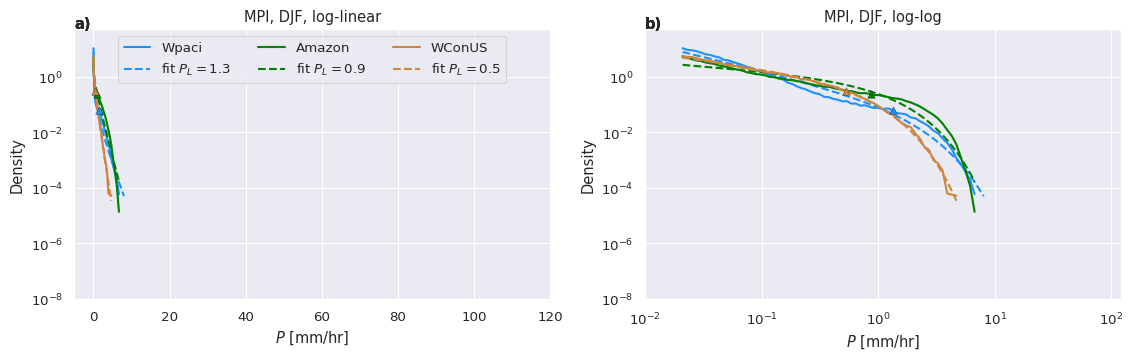

[np.int64(7), np.int64(5), np.int64(9)] [np.int64(11), np.int64(28), np.int64(25)]


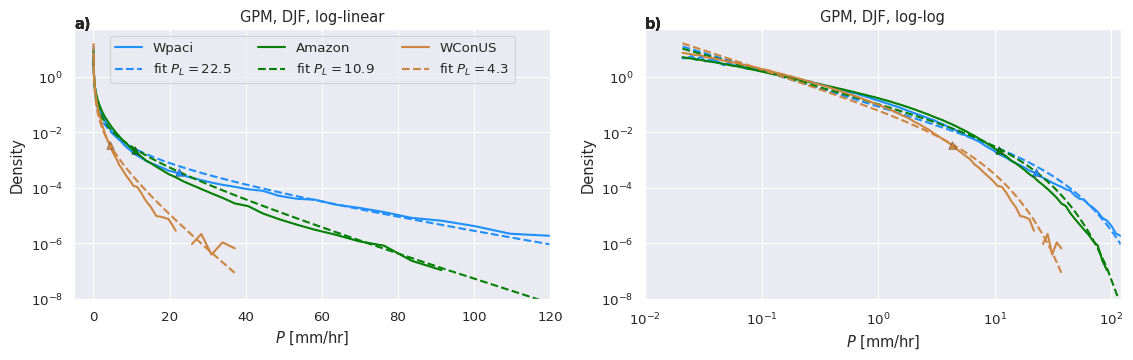

In [44]:
season = 'DJF'
regions = [
    {'name': 'Wpaci', 'center_lat': 15, 'center_lon': 120},
    {'name': 'Amazon', 'center_lat': -5, 'center_lon': 290},
    {'name': 'WConUS', 'center_lat': 40, 'center_lon': 260}
]
in_dir = '/scratch/leih/Precip_PDFs_4MDTF/output/model/'
source = 'MPI'
pdf_precip_plot(in_dir, season, source, regions)
in_dir = '/scratch/leih/Precip_PDFs_4MDTF/output/obs/'
source = 'GPM'
pdf_precip_plot(in_dir, season, source, regions)

In [30]:
#Temporarily replacing reading in the binned data

MM_ds_Precip = ds_PrecipPDFsParam.copy()
MM_ds_fit_PL_total_map = MM_ds_Precip['fit_PL_total']    
MM_ds_histNLogbin_Precip_total_map = MM_ds_Precip['histNLogbin_precip_total']    
MM_ds_histLogbin_Precip_total_map = MM_ds_Precip['histLogbin_precip_total'] 
MM_ds_X_fit_total_map = MM_ds_Precip['X_fit_total']    
MM_ds_Y_fit_total_map = MM_ds_Precip['Y_fit_total']


In [31]:
lat = MM_ds_Precip.lat_coarse.load().values
lon = MM_ds_Precip.lon_coarse.load().values
dlon = lon[1]-lon[0]
dlat = lat[1]-lat[0]
print(dlon,dlat)

9.375 9.350569485873173


In [32]:
lat

array([-55.16855153, -45.81798205, -36.46738914, -27.11678387,
       -17.76617169,  -8.41555576,   0.93506177,  10.28567913,
        19.63629451,  28.98690561,  38.33750895,  47.68809834,
        56.10360716])

In [37]:
lon

array([  4.21875,  13.59375,  22.96875,  32.34375,  41.71875,  51.09375,
        60.46875,  69.84375,  79.21875,  88.59375,  97.96875, 107.34375,
       116.71875, 126.09375, 135.46875, 144.84375, 154.21875, 163.59375,
       172.96875, 182.34375, 191.71875, 201.09375, 210.46875, 219.84375,
       229.21875, 238.59375, 247.96875, 257.34375, 266.71875, 276.09375,
       285.46875, 294.84375, 304.21875, 313.59375, 322.96875, 332.34375,
       341.71875, 351.09375, 357.65625])

In [33]:
# Select regions for plotting

idxlat_sel1WPaci = np.where(lat>10)[0][0]     
idxlon_sel1WPaci = np.where(lon>110)[0][0]
idxlat_sel1Amazon = np.where(lat>-10)[0][0]
idxlon_sel1Amazon = np.where(lon>290)[0][0]   
idxlat_sel1WConUS = np.where(lat>30)[0][0]     
idxlon_sel1WConUS = np.where(lon>240)[0][0]    

loc_name_list1 = ['WPaci','Amazon','WConUS']
loc_color_list1 = ['DodgerBlue','Green','Peru']
loc_lat_list1 = [idxlat_sel1WPaci, idxlat_sel1Amazon, idxlat_sel1WConUS]
loc_lon_list1 = [idxlon_sel1WPaci, idxlon_sel1Amazon, idxlon_sel1WConUS]

In [36]:
print(loc_lat_list1)
print(loc_lon_list1)

[np.int64(7), np.int64(5), np.int64(10)]
[np.int64(12), np.int64(31), np.int64(26)]


In [35]:
np.where(lat>-10)

(array([ 5,  6,  7,  8,  9, 10, 11, 12]),)

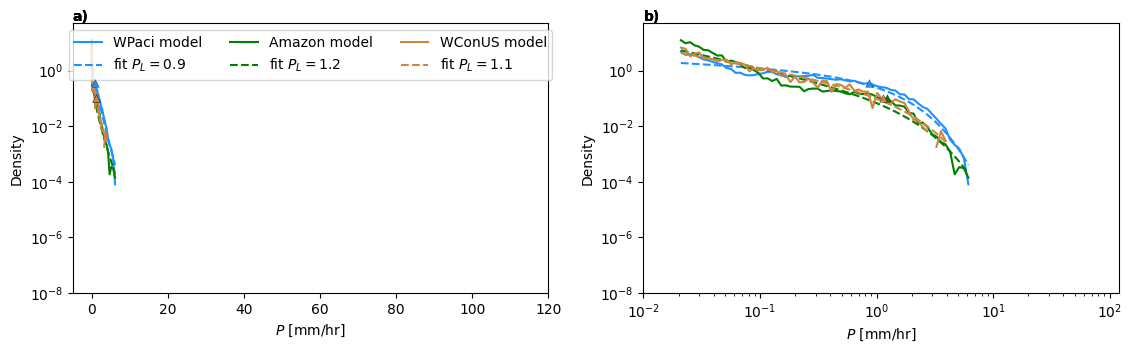

In [34]:
# import seaborn as sns
from matplotlib import pyplot as plt

# sns.set_style('darkgrid')
# sns.set_context("paper",font_scale=1.1)

fig, axs = plt.subplots(1,2, figsize=(13.5,3.5))
fig.subplots_adjust(wspace=0.2,hspace=0.3)
axs = axs.ravel()
panel_label = ['a)', 'b)', 'c)', 'd)']

# ss=0
# ds_histNLogbin_Precip_total_map = histNLogbin_Precip_total_map.sel(season=season_list[ss])
# ds_histLogbin_Precip_total_map = MM_ds_histLogbin_Precip_total_map.sel(season=season_list[ss])
# ds_fit_PL_total_map = MM_ds_fit_PL_total_map.sel(season=season_list[ss])

# ds_X_fit_total_map = MM_ds_X_fit_total_map.sel(season=season_list[ss])            
# ds_Y_fit_total_map = MM_ds_Y_fit_total_map.sel(season=season_list[ss])            

ds_histNLogbin_Precip_total_map = MM_ds_histNLogbin_Precip_total_map
ds_histLogbin_Precip_total_map = MM_ds_histLogbin_Precip_total_map
ds_fit_PL_total_map = MM_ds_fit_PL_total_map

ds_X_fit_total_map = MM_ds_X_fit_total_map          
ds_Y_fit_total_map = MM_ds_Y_fit_total_map       

            
for kk in range(len(loc_name_list1)):
    plot_x = ds_histNLogbin_Precip_total_map.Xbin[1:]
    plot_y = ds_histLogbin_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
    plot_y2 = ds_histNLogbin_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
    plot_y = np.ma.masked_where(plot_y2==0, plot_y)
    fit_x = ds_X_fit_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]
    fit_y = ds_Y_fit_total_map[loc_lat_list1[kk],loc_lon_list1[kk],1:]

    plot_x0 = ds_histNLogbin_Precip_total_map.Xbin[0]
    plot_y0 = ds_histLogbin_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],0]

    plot_x_PL = ds_fit_PL_total_map[loc_lat_list1[kk],loc_lon_list1[kk]]
    plot_y_PL = ds_histLogbin_Precip_total_map[loc_lat_list1[kk],loc_lon_list1[kk],:].sel(Xbin=plot_x_PL, method='nearest')

    ss1 = axs[0].plot(plot_x,plot_y,
                       c=loc_color_list1[kk],label=loc_name_list1[kk]+' model',linewidth=1.5,alpha=1)
    
    ll1 = axs[0].plot(fit_x,np.exp(fit_y),color=loc_color_list1[kk],linewidth=1.5,linestyle='--',label='fit $P_L=%.1f$'%plot_x_PL)

    ss01 = axs[0].scatter(plot_x_PL,plot_y_PL,s=30,marker='^',edgecolors='k',
               c=loc_color_list1[kk],linewidth=0.2,alpha=1,zorder=10)


    # axs[0].set_title('2001-2019, JJA, log-linear')

    axs[0].set_ylabel('Density')
    axs[0].set_xlabel('$P$ [mm/hr]')
    axs[0].set_yscale('log')
    # axs1.set_xscale('log')
    axs[0].set_xlim(-5,120)
    axs[0].set_ylim(1e-8, 5e1)
    axs[0].legend(loc='upper center',ncol=3)
    axs[0].text(0.0, 1.05, 'a)', weight='bold', va='top', ha='left', transform=axs[0].transAxes)


    ss1 = axs[1].plot(plot_x,plot_y,
                       c=loc_color_list1[kk],linewidth=1.5,alpha=1)
    
    ll1 = axs[1].plot(fit_x,np.exp(fit_y),color=loc_color_list1[kk],linewidth=1.5,linestyle='--')

    ss01 = axs[1].scatter(plot_x_PL,plot_y_PL,s=30,marker='^',edgecolors='k',
               c=loc_color_list1[kk],linewidth=0.2,alpha=1,zorder=10)


    # axs[1].set_title('2001-2019, JJA, log-log')

    axs[1].set_ylabel('Density')
    axs[1].set_xlabel('$P$ [mm/hr]')
    axs[1].set_yscale('log')
    axs[1].set_xscale('log')
    axs[1].set_xlim(1e-2,120)
    axs[1].set_ylim(1e-8, 5e1)
    # axs[1].legend(loc='lower center',ncol=3)
    axs[1].text(0.0, 1.05, 'b)', weight='bold', va='top', ha='left', transform=axs[1].transAxes)


### Plot precipitation PDFs for seasons 

### Similar plots but with x = P/P<sub>L</sub>

### Model vs observation comparison

<a id='section5'> </a>
## Section 5: More about this POD
- Detailed descriptions of the POD are documeneted in "diagnostics/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst" or click this [link]
(https://github.com/weiming9115/Working-Space/blob/master/MCS_precip_buoy_stats/doc/MCS_precip_buoy_stats.rst).